# Agent 1 Contact Expert 워크플로우 테스트

이 노트북은 `Contact Expert` (접촉 불량 전문가)의 독립적인 워크플로우를 테스트합니다.

## 주요 기능
- 테스트 이미지 로드
- Contact Expert 그래프 실행 (Step 1 -> Step 2 -> Step 3 -> Step 4)
- 결과 분석 및 리포트 출력

In [1]:
# 1. 초기 설정 및 라이브러리 임포트
import sys
import os
from pathlib import Path
import json
import base64

# 프로젝트 루트 경로 설정
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root))

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"✓ 프로젝트 루트: {project_root}")

✓ 프로젝트 루트: c:\Users\loidn\Documents\Projects\P_04_Scope


In [2]:
# 2. 테스트 이미지 준비
from src.utils import find_data_directory

try:
    data_dir = find_data_directory()
    test_image_name = "IMG_8113.jpg"
    test_image_path = Path(data_dir) / test_image_name
    
    if not test_image_path.exists():
        # 이미지가 없으면 첫 번째 가능한 이미지 사용
        image_files = list(Path(data_dir).glob("*.png")) + list(Path(data_dir).glob("*.jpg"))
        if image_files:
            test_image_path = image_files[0]
            print(f"⚠️ {test_image_name}을 찾을 수 없어 {test_image_path.name}을 사용합니다.")
        else:
            raise FileNotFoundError("테스트할 이미지가 없습니다.")
            
    print(f"✓ 테스트 이미지: {test_image_path}")
except Exception as e:
    print(f"❌ 오류: {e}")

✓ 테스트 이미지: c:\Users\loidn\Documents\Projects\P_04_Scope\data\IMG_8113.jpg


In [3]:
# 3. Payload 생성 함수
def create_payload(image_path):
    with open(image_path, 'rb') as f:
        image_data = f.read()
    
    ext = Path(image_path).suffix.lower()
    mime_type = 'image/png' if ext == '.png' else 'image/jpeg'
    image_base64 = base64.b64encode(image_data).decode('utf-8')
    
    return [
        {"text": "이미지를 분석하세요."},
        {"inline_data": {"mime_type": mime_type, "data": image_base64}}
    ]

In [4]:
# 4. Contact Expert 실행
from src.graphs.contact_expert_graph import contact_expert_wrapper_node
from src.state import InvestigationState

print("Contact Expert 분석 시작...")

payload = create_payload(test_image_path)

# InvestigationState 모의 구성
mock_state = InvestigationState(
    payload=payload,
    expert_reports=[],
    expert_analysis_results={},
    expert_confidence_scores={},
    expert_evidence={},
    final_verdict=None,
    errors=[],
    contact_cached_image_data=None
)

try:
    result = contact_expert_wrapper_node(mock_state)
    
    print("\n✓ 분석 완료!")
    print("=" * 60)
    
    # 결과 출력
    reports = result.get("expert_reports", [])
    if reports:
        print(reports[0])
    else:
        print("리포트가 생성되지 않았습니다.")
        
    print("=" * 60)
    print("세부 분석 결과:")
    analysis_results = result.get("expert_analysis_results", {}).get("contact", {})
    print(json.dumps(analysis_results, indent=2, ensure_ascii=False))
    
except Exception as e:
    print(f"❌ 실행 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()

Contact Expert 분석 시작...

🔍 [Step 1] 위치적 맥락 확인 시작... (이미지: 1237014 bytes)
✅ [Step 1] 완료: terminal

==================== Agent Reasoning & Tool Execution ====================
🛠️ [Tool Call]: crop_image (Args: {'image_path': 'C:\\Users\\loidn\\AppData\\Local\\Temp\\tmpxvso_4_v.jpg'})
   └─ 📊 [Tool Output]: 이미지 크롭 완료
- 원본 크기: 1568x1176
- 크롭된 크기: 1568x1176
🛠️ [Tool Call]: analyze_location_context_internal (Args: {'image_path': 'C:\\Users\\loidn\\AppData\\Local\\Temp\\tmpxvso_4_v.jpg'})
   └─ 📊 [Tool Output]: {"is_connection_point": true, "location_type": "terminal", "location_description": "전선이 금속 단자 구조물과 결합되는 끝단 부위 및 해당 지점의 전선 가닥들", "image_quality": "high", "image_quality_reason": "전반적인 조명과 초점이 양호하여 전선 가닥의 분리 및 단자 구조를 명확히 식별 가능함", "confidence": 85, "reasoning": "전선이 금속 단자에 체결된 부위 주변으로 집중적인 탄화 및 전선 가닥의 ...

🧠 [Thought]:
Final Answer: 분석 결과, 용융흔이 발생한 주요 위치는 **전선이 금속 단자 구조물과 결합되는 끝단(Terminal) 부위 및 해당 지점의 전선 가닥들**로 식별되었습니다.

상세 분석 내용은 다음과 같습니다:
1. **위치 및 형태**: 전선이 금속 단자에 체결된 부위 주변에서 집중적인 탄화와 전

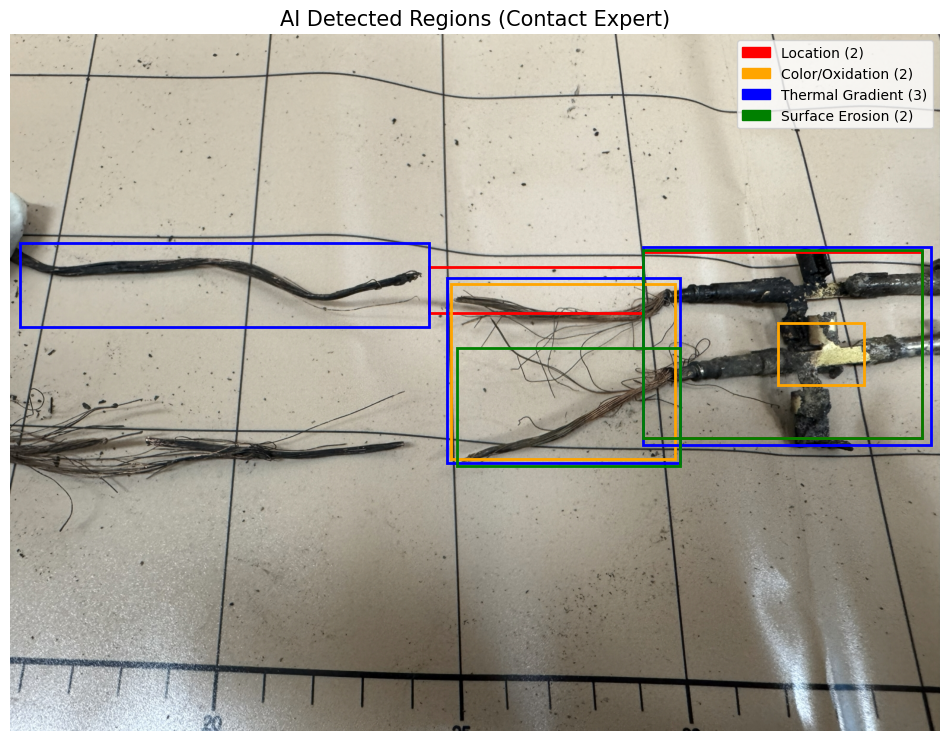

In [5]:
# 5. 분석 결과 시각화 (AI 검출 위치 표시)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io
import numpy as np

def draw_bounding_boxes(image_path, analysis_results):
    """
    분석 결과에 포함된 Bounding Box를 이미지 위에 표시합니다.
    """
    try:
        # 이미지 로드
        img = Image.open(image_path)
        original_width, original_height = img.size
        
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(img)
        ax.set_title("AI Detected Regions (Contact Expert)", fontsize=15)
        axis_off = True
        
        colors = {'step1': 'red', 'step2': 'orange', 'step3': 'blue', 'step4': 'green'}
        labels = {'step1': 'Location', 'step2': 'Color/Oxidation', 'step3': 'Thermal Gradient', 'step4': 'Surface Erosion'}
        
        legend_patches = []
        
        # 각 단계별 결과 시각화
        for step_key, color in colors.items():
            step_result = analysis_results.get(step_key, {})
            bboxes = step_result.get('bboxes', [])
            
            if bboxes:
                axis_off = False
                legend_patches.append(patches.Patch(color=color, label=f"{labels[step_key]} ({len(bboxes)})"))
                
                for box in bboxes:
                    # 0-1000 정규화 좌표 -> 픽셀 좌표 변환
                    # box format: [ymin, xmin, ymax, xmax]
                    ymin, xmin, ymax, xmax = box
                    
                    x = xmin / 1000 * original_width
                    y = ymin / 1000 * original_height
                    w = (xmax - xmin) / 1000 * original_width
                    h = (ymax - ymin) / 1000 * original_height
                    
                    # 사각형 그리기
                    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    
                    # 텍스트 레이블 (선택적)
                    # ax.text(x, y - 5, labels[step_key], color=color, fontsize=10, weight='bold')

        if legend_patches:
            ax.legend(handles=legend_patches, loc='upper right')
            
        plt.axis('off')
        plt.show()
        
        if not legend_patches:
            print("검출된 Bounding Box 정보가 없습니다.")
            
    except Exception as e:
        print(f"시각화 중 오류 발생: {e}")

# 시각화 함수 실행
if 'test_image_path' in locals() and 'result' in locals():
    analysis_results = result.get("expert_analysis_results", {}).get("contact", {})
    draw_bounding_boxes(test_image_path, analysis_results)
else:
    print("테스트 이미지 경로 또는 분석 결과가 없습니다.")